In [2]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)


%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch

import pandas as pd
import numpy.matlib as matlib
import scipy
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO


from phaseEM import *
from extract_features import *
from channel_evaluation import *
from reconstruction_minimal import reconstruct
import config as cfg
from notebookfunctions import *

import gc

feat_path = r'./features'
result_path = r'./results'

In [2]:



winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
path_output = r'./features'
pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']




phase_unstacked_dict = {}
phase_data_dict = {}
for pt in pts: 
    io = NWBHDF5IO(os.path.join(path_bids,pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    data = nwbfile.acquisition['iEEG'].data
    #io.close()
    
    initParams_list = get_initParams(pt)
    feat = extractSSPE(data, initParams_list, include_phase = True, include_pac = False)
    phase_unstacked_dict[pt] = feat
    np.save(os.path.join(path_output,f'{pt}_PHASE_SSPEfeat.npy'), feat)
    phase_data_dict[pt] = stackFeatures(feat)
    io.close()
    del data
    gc.collect()

reconstruct(pts=None, SSPEfeatures=False, given_data=True, data_dict=phase_data_dict, saveAs='phase_sppe')







nr of frequencies in somata results in total: 395
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 307
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 478
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 304
Starting parallel SSPE extraction for 115 channels...
nr of frequencies in somata results in total: 199
Starting parallel SSPE extraction for 60 channels...
nr of frequencies in somata results in total: 67
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 481
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 174
Starting parallel SSPE extraction for 54 channels...
nr of frequencies in somata results in total: 304
Starting parallel SSPE extraction for 117 channels...
nr of frequencies in somata results in total: 346
Starting parallel

AssertionError: Channel 9 appears to have no HG oscillator

(10, 10, 23)
(10, 10, 23)


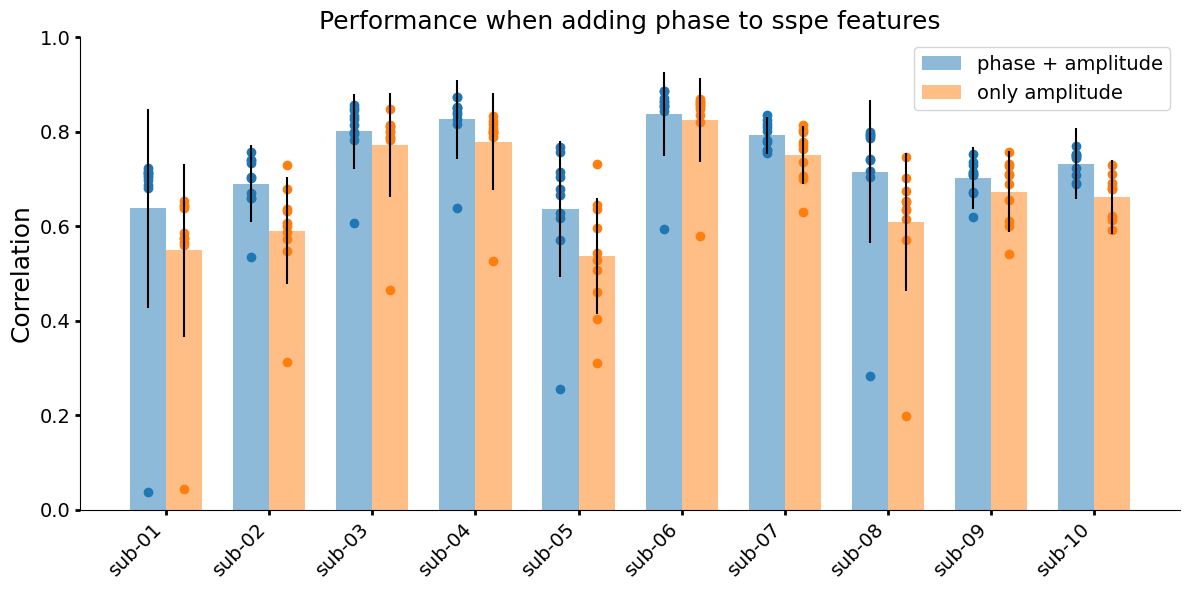

In [16]:
viz_compare_results('phase_sppe', 'SSPE_PLS', name_a = 'phase + amplitude', name_b = 'only amplitude', title = 'Performance when adding phase to sspe features')

#Documents/DSAI_year2/SingleWordProductionDutch-1/results/phase_sppelinearResults.npy

(10, 10, 23)
(10, 10, 23)


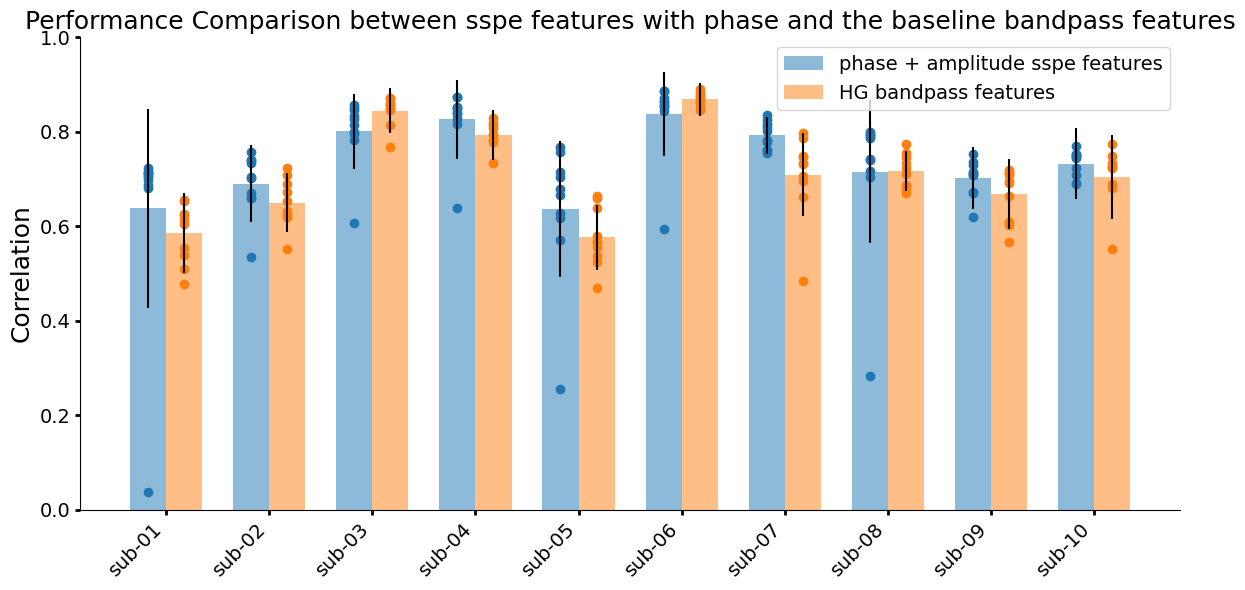

In [18]:
viz_compare_results('phase_sppe', 'Bandpass_PLS',name_a = 'phase + amplitude sspe features', name_b = 'HG bandpass features', title = 'Performance Comparison between sspe features with phase and the baseline bandpass features')


In [3]:
winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
path_output = r'./features'
pts = ['sub-07', 'sub-08', 'sub-09', 'sub-10']



unstacked_dict = {}
data_dict = {}
for pt in pts: 
    io = NWBHDF5IO(os.path.join(path_bids,pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    data = nwbfile.acquisition['iEEG'].data
    #io.close()
    
    initParams_list = get_initParams(pt)
    feat = extractSSPE(data, initParams_list, include_phase = True, include_pac = True)
    unstacked_dict[pt] = feat
    np.save(os.path.join(path_output,f'{pt}_PCA_SSPEfeat.npy'), feat)
    data_dict[pt] = stackFeatures(feat)
    io.close()
    del data
    gc.collect()

nr of frequencies in somata results in total: 481
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 174
Starting parallel SSPE extraction for 54 channels...
nr of frequencies in somata results in total: 304
Starting parallel SSPE extraction for 117 channels...
nr of frequencies in somata results in total: 346
Starting parallel SSPE extraction for 122 channels...


KeyError: 'sub-01'

In [12]:
pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06']

reconstruct(pts=pts, SSPEfeatures=False, given_data=True, data_dict=data_dict, saveAs='PAC_sppe')

sub-01 has mean correlation of 0.640016


KeyboardInterrupt: 

In [3]:

path_output = r'./features'
pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']


reconstruct(pts=pts, feat_suffix='_PCA_SSPEfeat.npy', unstacked =True, saveAs='PAC_sppe')


KeyboardInterrupt: 